In [1]:
# Cell 1 — Imports + global setup
import itertools
import random
import time
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

GLOBAL_SEED = 42

# Experiment design
SEEDS = [0, 1, 2, 3, 4]          # show each seed
BUDGET = 60                      # model trainings per method per seed
GA_POP = 10
GA_GENS = 6                      
assert GA_POP * GA_GENS == BUDGET

# Training knobs 
MAX_ITERS = 80
EARLY_STOP = True

print("Seeds:", SEEDS)
print("Budget per method per seed:", BUDGET)
print("GA:", GA_POP, "pop x", GA_GENS, "gens")

Seeds: [0, 1, 2, 3, 4]
Budget per method per seed: 60
GA: 10 pop x 6 gens


In [2]:
# Cell 2 — Data + split
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

# Split dataset into 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=GLOBAL_SEED, stratify=y
)
# Take the 80% train+val data and split into 75% train, 25% val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=GLOBAL_SEED, stratify=y_trainval
)

# Show data shapes.
print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

Train/Val/Test: (1077, 64) (360, 64) (360, 64)


In [3]:
# Cell 3 — Search space + helpers

# Define the hyperparameter search space for the MLPClassifier. Each key maps to a list of possible values for that hyperparameter.
SEARCH_SPACE = {
    "lr": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    "layers": [1, 2, 3, 4],
    "width": [32, 64, 128, 256],
    "batch": [16, 32, 64, 128],
    "activation": ["relu", "tanh"],
}

# Helper functions to convert between cfg dicts and strings, sample random cfgs, build pipelines, and evaluate val/test acc.
def make_hidden(layers: int, width: int) -> Tuple[int, ...]:
    return tuple([width] * layers)

# Convert cfg dict to a readable string for printing.
def cfg_to_str(cfg: Dict) -> str:
    return f"lr={cfg['lr']}, layers={cfg['layers']}, width={cfg['width']}, batch={cfg['batch']}, act={cfg['activation']}"

# Convert cfg dict to a readable string for printing.
def best_so_far_curve(scores: List[float]) -> List[float]:
    best = -1.0
    out = []
    for s in scores:
        best = max(best, s)
        out.append(best)
    return out

# Sample a random cfg from the search space using the provided random number generator.
def sample_random_cfg(rng: random.Random) -> Dict:
    return {
        "lr": rng.choice(SEARCH_SPACE["lr"]),
        "layers": rng.choice(SEARCH_SPACE["layers"]),
        "width": rng.choice(SEARCH_SPACE["width"]),
        "batch": rng.choice(SEARCH_SPACE["batch"]),
        "activation": rng.choice(SEARCH_SPACE["activation"]),
    }

# Build a sklearn Pipeline with a StandardScaler and an MLPClassifier using the provided cfg and seed.
def build_pipeline(cfg: Dict, seed: int) -> Pipeline:
    hidden = make_hidden(cfg["layers"], cfg["width"])
    # # Initialize the fully connected neural network (FCNN) with the current hyperparameters.
    clf = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=cfg["activation"],
        solver="adam",
        learning_rate_init=cfg["lr"],
        batch_size=cfg["batch"],
        max_iter=MAX_ITERS,
        early_stopping=EARLY_STOP,
        n_iter_no_change=10,
        validation_fraction=0.1,
        random_state=seed,
        tol=1e-4,
        verbose=False,
    )
    return Pipeline([("scaler", StandardScaler()), ("mlp", clf)])

# Train the model with the provided cfg and seed, evaluate on the validation set, and return the validation accuracy.
def train_eval_valacc(cfg: Dict, seed: int) -> float:
    pipe = build_pipeline(cfg, seed)
    pipe.fit(X_train, y_train)
    yhat = pipe.predict(X_val)
    return float(accuracy_score(y_val, yhat))

# Train the model with the provided cfg and seed, evaluate on the test set, and return the test accuracy.
def train_eval_testacc(cfg: Dict, seed: int) -> float:
    # Train on train+val, evaluate on test (simulate final model selection and retraining on all data).
    pipe = build_pipeline(cfg, seed)
    pipe.fit(np.vstack([X_train, X_val]), np.concatenate([y_train, y_val]))
    yhat = pipe.predict(X_test)
    return float(accuracy_score(y_test, yhat))

# Precompute full grid, but we will only evaluate the first BUDGET points to keep equal budgets.
grid_all = list(itertools.product(
    SEARCH_SPACE["lr"], SEARCH_SPACE["layers"], SEARCH_SPACE["width"], SEARCH_SPACE["batch"], SEARCH_SPACE["activation"]
))
print("Total grid size:", len(grid_all))
print("Using first", BUDGET, "grid points per seed for fairness.")

Total grid size: 640
Using first 60 grid points per seed for fairness.



==== OVERALL BEST CONFIGURATION FOUND BY GRID SEARCH (across all seeds) ====
Best Performing Seed: 1
Best Validation Accuracy: 0.9806
Test Accuracy of best Config: 0.9833
Best Neural Network Config Found: lr=0.0001, layers=2, width=256, batch=32, act=relu


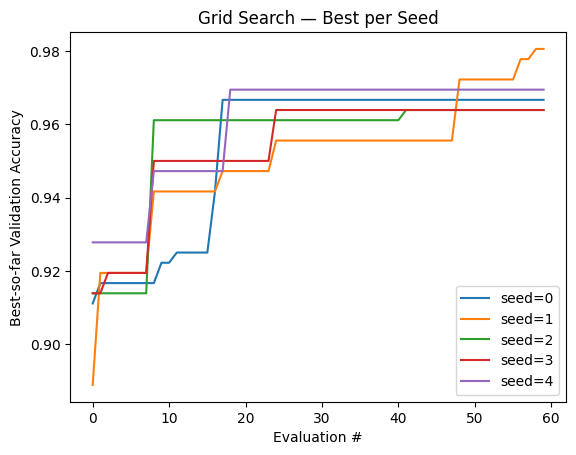

,seed,method,best_val_acc,best_test_acc,best_cfg,avg_val_acc,median_val_acc,avg_eval_time_s,total_time_s
0,1,Grid Search,0.980556,0.983333,"lr=0.0001, layers=2, width=256, batch=32, act=...",0.902870,0.919444,1.115884,71.294756
1,4,Grid Search,0.969444,0.958333,"lr=0.0001, layers=1, width=128, batch=32, act=...",0.894954,0.909722,1.088338,66.604512
2,0,Grid Search,0.966667,0.941667,"lr=0.0001, layers=1, width=128, batch=16, act=...",0.898519,0.913889,1.126114,68.745678
3,2,Grid Search,0.963889,0.975000,"lr=0.0001, layers=2, width=64, batch=16, act=tanh",0.902731,0.916667,1.161048,71.939045
4,3,Grid Search,0.963889,0.972222,"lr=0.0001, layers=1, width=256, batch=16, act=...",0.894213,0.911111,1.218142,75.210520


In [4]:
# Cell 4 — Baseline 1: Grid Search (all seeds) + per-seed visuals

grid_results = []     # row-wise results
grid_curves = {}      # seed -> best-so-far curve

# Grid search: evaluate first BUDGET points of the grid for each seed, track best-so-far curve, and final test acc of best val cfg.
for seed in SEEDS:
    scores = []
    cfgs = []
    eval_times = []

    start = time.time()
    # Iterate over the first BUDGET points of the precomputed grid, evaluate val acc, and track eval times.
    for i, (lr, layers, width, batch, activation) in enumerate(grid_all[:BUDGET], start=1):
        cfg = {"lr": lr, "layers": layers, "width": width, "batch": batch, "activation": activation}

        t0 = time.time()
        acc = train_eval_valacc(cfg, seed=seed * 10_000 + i)   # deterministic per seed
        t1 = time.time()

        scores.append(acc)
        cfgs.append(cfg)
        eval_times.append(t1 - t0)

    best_idx = int(np.argmax(scores))
    best_cfg = cfgs[best_idx]
    best_val = scores[best_idx]
    best_test = train_eval_testacc(best_cfg, seed=seed * 10_000 + 99_999)

    grid_curves[seed] = best_so_far_curve(scores)

    grid_results.append({
        "seed": seed,
        "method": "Grid Search",
        "best_val_acc": best_val,
        "best_test_acc": best_test,
        "best_cfg": cfg_to_str(best_cfg),
        "avg_val_acc": float(np.mean(scores)),
        "median_val_acc": float(np.median(scores)),
        "avg_eval_time_s": float(np.mean(eval_times)),
        "total_time_s": float(time.time() - start),
    })

# Gets the best performing row
best_dict = max(grid_results, key=lambda d: d["best_val_acc"])
print("\n==== OVERALL BEST CONFIGURATION FOUND BY GRID SEARCH (across all seeds) ====")
print(f"Best Performing Seed: {best_dict['seed']}")
print(f"Best Validation Accuracy: {best_dict['best_val_acc']:.4f}")
print(f"Test Accuracy of best Config: {best_dict['best_test_acc']:.4f}")
print(f"Best Neural Network Config Found: {best_dict['best_cfg']}")

# Visual: show EACH seed curve for grid
plt.figure()
for seed in SEEDS:
    plt.plot(grid_curves[seed], label=f"seed={seed}")
plt.xlabel("Evaluation #")
plt.ylabel("Best-so-far Validation Accuracy")
plt.title("Grid Search — Best per Seed")
plt.legend()
plt.show()

# Show grid results sorted by best_val_acc.
pd.DataFrame(grid_results).sort_values(["best_val_acc"], ascending=False).reset_index(drop=True)


==== OVERALL BEST CONFIGURATION FOUND BY RANDOM SEARCH (across all seeds) ====
Best Performing Seed: 3
Best Validation Accuracy: 0.9833
Test Accuracy of best Config: 0.9722
Best Neural Network Config Found: lr=0.01, layers=1, width=256, batch=64, act=relu


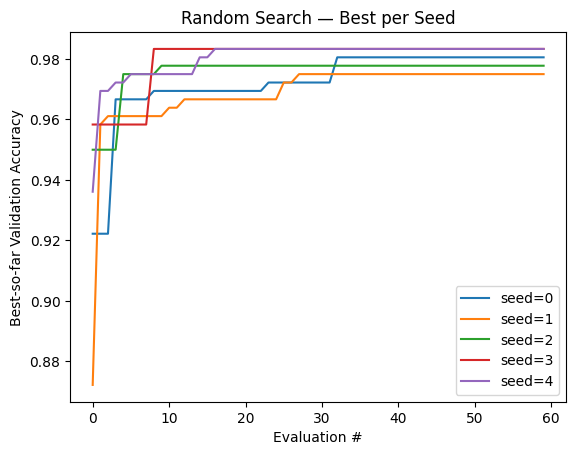

,seed,method,best_val_acc,best_test_acc,best_cfg,avg_val_acc,median_val_acc,avg_eval_time_s,total_time_s
0,3,Random Search,0.983333,0.972222,"lr=0.01, layers=1, width=256, batch=64, act=relu",0.946528,0.952778,0.882741,53.390491
1,4,Random Search,0.983333,0.972222,"lr=0.003, layers=2, width=256, batch=16, act=relu",0.940787,0.947222,0.775361,49.125975
2,0,Random Search,0.980556,0.925000,"lr=0.01, layers=2, width=64, batch=16, act=relu",0.941991,0.952778,0.856323,51.889627
3,2,Random Search,0.977778,0.975000,"lr=0.001, layers=4, width=256, batch=32, act=relu",0.936204,0.950000,1.075017,68.249324
4,1,Random Search,0.975000,0.972222,"lr=0.0003, layers=4, width=256, batch=16, act=...",0.935370,0.952778,1.392660,92.002042


In [5]:
# Cell 5 — Baseline 2: Random Search (all seeds) + per-seed visuals

rand_results = []
rand_curves = {}

# Random search: sample BUDGET random points for each seed, track best-so-far curve, and final test acc of best val cfg.
for seed in SEEDS:
    rng = random.Random(GLOBAL_SEED + seed)
    scores = []
    cfgs = []
    eval_times = []

    start = time.time()
    # Iterate over BUDGET random samples, evaluate val acc, and track eval times.
    for i in range(1, BUDGET + 1):
        cfg = sample_random_cfg(rng)

        t0 = time.time()
        acc = train_eval_valacc(cfg, seed=seed * 10_000 + 1_000 + i)
        t1 = time.time()

        scores.append(acc)
        cfgs.append(cfg)
        eval_times.append(t1 - t0)

    best_idx = int(np.argmax(scores))
    best_cfg = cfgs[best_idx]
    best_val = scores[best_idx]
    best_test = train_eval_testacc(best_cfg, seed=seed * 10_000 + 199_999)

    rand_curves[seed] = best_so_far_curve(scores)

    rand_results.append({
        "seed": seed,
        "method": "Random Search",
        "best_val_acc": best_val,
        "best_test_acc": best_test,
        "best_cfg": cfg_to_str(best_cfg),
        "avg_val_acc": float(np.mean(scores)),
        "median_val_acc": float(np.median(scores)),
        "avg_eval_time_s": float(np.mean(eval_times)),
        "total_time_s": float(time.time() - start),
    })

# Gets the best performing row
best_dict = max(rand_results, key=lambda d: d["best_val_acc"])
print("\n==== OVERALL BEST CONFIGURATION FOUND BY RANDOM SEARCH (across all seeds) ====")
print(f"Best Performing Seed: {best_dict['seed']}")
print(f"Best Validation Accuracy: {best_dict['best_val_acc']:.4f}")
print(f"Test Accuracy of best Config: {best_dict['best_test_acc']:.4f}")
print(f"Best Neural Network Config Found: {best_dict['best_cfg']}")

# Visual: show EACH seed curve for random
plt.figure()
for seed in SEEDS:
    plt.plot(rand_curves[seed], label=f"seed={seed}")
plt.xlabel("Evaluation #")
plt.ylabel("Best-so-far Validation Accuracy")
plt.title("Random Search — Best per Seed")
plt.legend()
plt.show()

# Show random results sorted by best_val_acc.
pd.DataFrame(rand_results).sort_values(["best_val_acc"], ascending=False).reset_index(drop=True)


==== OVERALL BEST CONFIGURATION FOUND BY GENETIC ALGORITHM (across all seeds) ====
Best Performing Seed: 0
Best Validation Accuracy: 0.9833
Test Accuracy of best Config: 0.9694
Best Neural Network Config Found: lr=0.001, layers=4, width=128, batch=16, act=relu


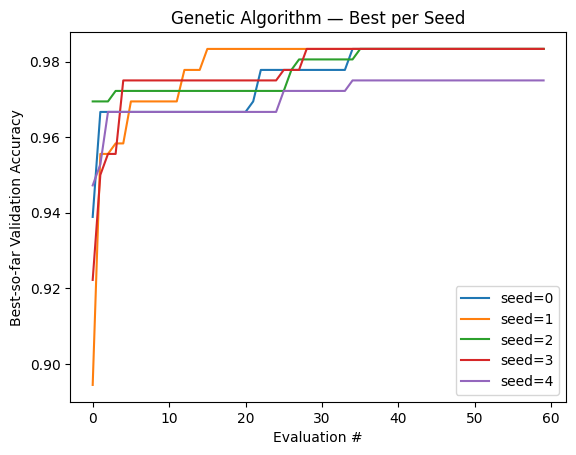

,seed,method,best_val_acc,best_test_acc,best_cfg,avg_val_acc,median_val_acc,avg_eval_time_s,total_time_s
0,0,Genetic Algorithm,0.983333,0.969444,"lr=0.001, layers=4, width=128, batch=16, act=relu",0.952454,0.956944,0.707521,44.063885
1,1,Genetic Algorithm,0.983333,0.972222,"lr=0.001, layers=4, width=256, batch=32, act=relu",0.956019,0.958333,0.973866,62.757898
2,2,Genetic Algorithm,0.983333,0.963889,"lr=0.001, layers=4, width=256, batch=32, act=relu",0.956389,0.959722,1.691307,104.920685
3,3,Genetic Algorithm,0.983333,0.977778,"lr=0.001, layers=4, width=256, batch=32, act=relu",0.958426,0.959722,1.364821,85.750653
4,4,Genetic Algorithm,0.975000,0.961111,"lr=0.0003, layers=2, width=256, batch=64, act=...",0.952315,0.958333,1.723831,104.987760



=== GA per-generation bests (seed=0) ===


,seed,generation,gen_best_val_acc,gen_best_cfg
0,0,0,0.966667,"lr=0.001, layers=2, width=32, batch=32, act=relu"
1,0,1,0.963889,"lr=0.01, layers=3, width=64, batch=32, act=tanh"
2,0,2,0.977778,"lr=0.001, layers=2, width=128, batch=128, act=..."
3,0,3,0.983333,"lr=0.001, layers=4, width=128, batch=16, act=relu"
4,0,4,0.972222,"lr=0.001, layers=3, width=128, batch=128, act=..."
5,0,5,0.969444,"lr=0.01, layers=3, width=64, batch=32, act=tanh"



=== GA per-generation bests (seed=1) ===


,seed,generation,gen_best_val_acc,gen_best_cfg
0,1,0,0.969444,"lr=0.003, layers=1, width=64, batch=64, act=relu"
1,1,1,0.983333,"lr=0.001, layers=4, width=256, batch=32, act=relu"
2,1,2,0.977778,"lr=0.003, layers=2, width=256, batch=64, act=relu"
3,1,3,0.966667,"lr=0.01, layers=1, width=64, batch=64, act=relu"
4,1,4,0.969444,"lr=0.01, layers=3, width=64, batch=64, act=relu"
5,1,5,0.980556,"lr=0.003, layers=1, width=256, batch=64, act=relu"


...

,seed,generation,gen_best_val_acc,gen_best_cfg
0,2,0,0.972222,"lr=0.0003, layers=2, width=128, batch=32, act=..."
1,2,1,0.969444,"lr=0.003, layers=1, width=256, batch=32, act=tanh"
2,2,2,0.980556,"lr=0.001, layers=3, width=256, batch=16, act=relu"
3,2,3,0.983333,"lr=0.001, layers=4, width=256, batch=32, act=relu"
4,2,4,0.980556,"lr=0.003, layers=1, width=256, batch=16, act=relu"
5,2,5,0.977778,"lr=0.003, layers=1, width=256, batch=16, act=relu"



=== GA per-generation bests (seed=3) ===


,seed,generation,gen_best_val_acc,gen_best_cfg
0,3,0,0.975000,"lr=0.003, layers=3, width=256, batch=32, act=relu"
1,3,1,0.972222,"lr=0.003, layers=1, width=256, batch=32, act=relu"
2,3,2,0.983333,"lr=0.001, layers=4, width=256, batch=32, act=relu"
3,3,3,0.983333,"lr=0.003, layers=3, width=128, batch=32, act=tanh"
4,3,4,0.983333,"lr=0.003, layers=3, width=64, batch=16, act=tanh"
5,3,5,0.980556,"lr=0.003, layers=3, width=256, batch=16, act=tanh"



=== GA per-generation bests (seed=4) ===


,seed,generation,gen_best_val_acc,gen_best_cfg
0,4,0,0.966667,"lr=0.0003, layers=2, width=256, batch=32, act=..."
1,4,1,0.966667,"lr=0.0003, layers=1, width=256, batch=32, act=..."
2,4,2,0.972222,"lr=0.01, layers=2, width=256, batch=64, act=tanh"
3,4,3,0.975000,"lr=0.0003, layers=2, width=256, batch=64, act=..."
4,4,4,0.969444,"lr=0.0003, layers=2, width=256, batch=16, act=..."
5,4,5,0.975000,"lr=0.003, layers=2, width=256, batch=16, act=tanh"


In [6]:
# Cell 6 — Method 3: Genetic Algorithm (all seeds) + per-seed visuals + GA-only tables

# Helper functions for tournament selection, uniform crossover, and mutation.
def tournament_select(pop: List[Dict], fits: List[float], rng: random.Random, k: int = 3) -> Dict:
    idxs = rng.sample(range(len(pop)), k)
    best = max(idxs, key=lambda j: fits[j])
    return pop[best]

# Uniform crossover between two parent cfgs to produce a child cfg. Each hyperparameter is randomly chosen from one of the parents with equal probability.
def uniform_crossover(a: Dict, b: Dict, rng: random.Random) -> Dict:
    child = {}
    for key in a.keys():
        child[key] = a[key] if rng.random() < 0.5 else b[key]
    return child

# Mutation of a child cfg with probability pmut per hyperparameter. Each mutated hyperparameter is replaced with a random choice from the search space.
def mutate(cfg: Dict, rng: random.Random, pmut: float = 0.25) -> Dict:
    out = dict(cfg)
    for key, options in SEARCH_SPACE.items():
        if rng.random() < pmut:
            out[key] = rng.choice(options)
    return out

ga_results = []
ga_curves = {}
ga_gen_tables = {} 

# GA search: run GA for each seed, track best-so-far curve, per-generation bests, and final test acc of best val cfg.
for seed in SEEDS:
    ga_rng = random.Random(GLOBAL_SEED + 10_000 + seed)
    pop = [sample_random_cfg(ga_rng) for _ in range(GA_POP)]

    all_scores = []
    all_cfgs = []
    gen_best_rows = []
    eval_times = []  

    start = time.time()
    eval_counter = 0

# Iterate over generations, evaluate each cfg in the population, and track eval times.
    for gen in range(GA_GENS):
        fits = []
        for i in range(GA_POP):
            eval_counter += 1
            cfg = pop[i]

            t0 = time.time()
            acc = train_eval_valacc(cfg, seed=seed * 10_000 + 2_000 + eval_counter)
            t1 = time.time()

            eval_times.append(t1 - t0)
            fits.append(acc)
            all_scores.append(acc)
            all_cfgs.append(cfg)

        best_i = int(np.argmax(fits))
        elite_cfg = pop[best_i]
        elite_fit = fits[best_i]

        gen_best_rows.append({
            "seed": seed,
            "generation": gen,
            "gen_best_val_acc": elite_fit,
            "gen_best_cfg": cfg_to_str(elite_cfg),
        })

        # next generation with elitism=1
        next_pop = [elite_cfg]
        while len(next_pop) < GA_POP:
            p1 = tournament_select(pop, fits, ga_rng, k=3)
            p2 = tournament_select(pop, fits, ga_rng, k=3)
            child = uniform_crossover(p1, p2, ga_rng)
            child = mutate(child, ga_rng, pmut=0.25)
            next_pop.append(child)
        pop = next_pop

    best_idx = int(np.argmax(all_scores))
    best_cfg = all_cfgs[best_idx]
    best_val = all_scores[best_idx]
    best_test = train_eval_testacc(best_cfg, seed=seed * 10_000 + 299_999)

    ga_curves[seed] = best_so_far_curve(all_scores)

    ga_results.append({
        "seed": seed,
        "method": "Genetic Algorithm",
        "best_val_acc": best_val,
        "best_test_acc": best_test,
        "best_cfg": cfg_to_str(best_cfg),
        "avg_val_acc": float(np.mean(all_scores)),
        "median_val_acc": float(np.median(all_scores)),
        "avg_eval_time_s": float(np.mean(eval_times)), 
        "total_time_s": float(time.time() - start),
    })

    ga_gen_tables[seed] = pd.DataFrame(gen_best_rows)

# Gets the best performing row
best_dict = max(ga_results, key=lambda d: d["best_val_acc"])
print("\n==== OVERALL BEST CONFIGURATION FOUND BY GENETIC ALGORITHM (across all seeds) ====")
print(f"Best Performing Seed: {best_dict['seed']}")
print(f"Best Validation Accuracy: {best_dict['best_val_acc']:.4f}")
print(f"Test Accuracy of best Config: {best_dict['best_test_acc']:.4f}")
print(f"Best Neural Network Config Found: {best_dict['best_cfg']}")

# GA-only independent visuals
plt.figure()
for seed in SEEDS:
    plt.plot(ga_curves[seed], label=f"seed={seed}")
plt.xlabel("Evaluation #")
plt.ylabel("Best-so-far Validation Accuracy")
plt.title("Genetic Algorithm — Best per Seed")
plt.legend()
plt.show()

# Show GA results sorted by best_val_acc.
display(pd.DataFrame(ga_results).sort_values(["best_val_acc"], ascending=False).reset_index(drop=True))

# GA-only generation tables
for seed in SEEDS:
    print(f"\n=== GA per-generation bests (seed={seed}) ===")
    display(ga_gen_tables[seed])

=== Best Configurations per Seed ===


,method,seed,best_val_acc,best_test_acc,best_cfg,total_time_s
0,Genetic Algorithm,0,0.983333,0.969444,"lr=0.001, layers=4, width=128, batch=16, act=relu",44.063885
1,Genetic Algorithm,1,0.983333,0.972222,"lr=0.001, layers=4, width=256, batch=32, act=relu",62.757898
2,Genetic Algorithm,2,0.983333,0.963889,"lr=0.001, layers=4, width=256, batch=32, act=relu",104.920685
3,Genetic Algorithm,3,0.983333,0.977778,"lr=0.001, layers=4, width=256, batch=32, act=relu",85.750653
4,Genetic Algorithm,4,0.975000,0.961111,"lr=0.0003, layers=2, width=256, batch=64, act=...",104.987760
5,Grid Search,0,0.966667,0.941667,"lr=0.0001, layers=1, width=128, batch=16, act=...",68.745678
6,Grid Search,1,0.980556,0.983333,"lr=0.0001, layers=2, width=256, batch=32, act=...",71.294756
7,Grid Search,2,0.963889,0.975000,"lr=0.0001, layers=2, width=64, batch=16, act=tanh",71.939045
8,Grid Search,3,0.963889,0.972222,"lr=0.0001, layers=1, width=256, batch=16, act=...",75.210520
9,Grid Search,4,0.969444,0.958333,"lr=0.0001, layers=1, width=128, batch=32, act=...",66.604512



=== Convergence Metrics ===
Evals to 95% (Mean): The average number of model evaluations required to reach 95% of the algorithm's final best accuracy.
Evals to 99% (Mean): The average number of evaluations required to reach 99% of its final best accuracy.
Note: Lower numbers indicate faster, more efficient convergence.



,Method,Final Best Score (Mean),Evals to 95% (Mean),Evals to 99% (Mean)
0,Grid Search,0.9689,6.4,24.0
1,Random Search,0.9800,1.8,11.4
2,Genetic Algorithm,0.9817,1.4,14.2


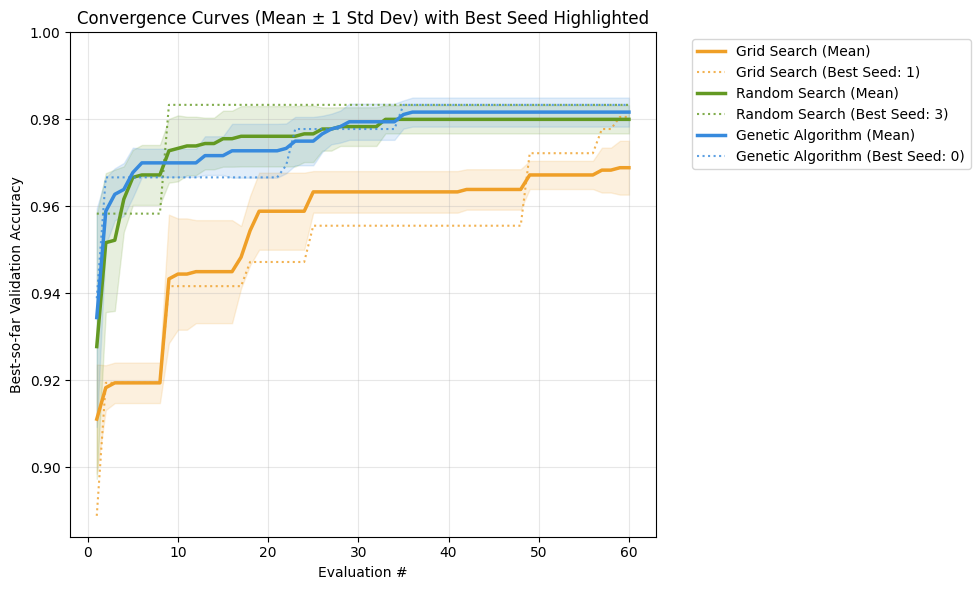

In [7]:
# Cell 7 — average (and best) best-so-far curves across seeds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Helper Functions ---

# Pad curves to the same length by holding the last value, so we can compute mean and std dev across seeds.
def pad_to_len(curves: list[list[float]], L: int) -> np.ndarray:
    arr = []
    for c in curves:
        if len(c) < L:
            c = c + [c[-1]] * (L - len(c))
        arr.append(c[:L])
    return np.array(arr, dtype=float)

# Compute mean and std dev of best-so-far curves across seeds for each method. Returns two arrays of shape (L,) where L is the max curve length.
def mean_std_curve(curve_dict: dict[int, list[float]]) -> tuple[np.ndarray, np.ndarray]:
    # curve_dict: seed -> curve list
    curves = list(curve_dict.values())
    L = max(len(c) for c in curves)
    mat = pad_to_len(curves, L)
    return mat.mean(axis=0), mat.std(axis=0)

# Compute where curve crosses threshold percentage
def evals_to_threshold(curve, threshold_percent):
    final_value = curve[-1]
    target = final_value * (threshold_percent / 100.0)
    for i, val in enumerate(curve):
        if val >= target:
            return i + 1
    return len(curve)

# Get the seed with the best final val acc for a given method, so we can highlight its curve in the final visual.
def best_seed_by_metric(rows: pd.DataFrame, method: str, metric: str = "best_val_acc") -> int:
    sub = rows[rows["method"] == method].copy()
    return int(sub.sort_values(metric, ascending=False).iloc[0]["seed"])

# --- Build Table ---

# Build a single dataframe with all results for easy comparison and final table display.
all_rows = pd.DataFrame(grid_results + rand_results + ga_results)

# Final visual: plot mean best-so-far curve with error bars for each method, and highlight the best seed curve for each method.
best_cfg_table = all_rows[["method","seed","best_val_acc","best_test_acc","best_cfg","total_time_s"]].copy()
best_cfg_table = best_cfg_table.sort_values(["method","seed"]).reset_index(drop=True)

print("=== Best Configurations per Seed ===")
display(best_cfg_table)

# --- Convergence Analysis ---

methods_data = [
    ("Grid Search", grid_curves),
    ("Random Search", rand_curves),
    ("Genetic Algorithm", ga_curves)
]

convergence_records = []

for method_name, curves_dict in methods_data:
    e95_list, e99_list = [], []
    final_scores = []
    
    for seed, curve in curves_dict.items():
        e95_list.append(evals_to_threshold(curve, 95))
        e99_list.append(evals_to_threshold(curve, 99))
        final_scores.append(curve[-1])
        
    convergence_records.append({
        "Method": method_name,
        "Final Best Score (Mean)": np.round(np.mean(final_scores), 4),
        "Evals to 95% (Mean)": np.round(np.mean(e95_list), 1),
        "Evals to 99% (Mean)": np.round(np.mean(e99_list), 1),
    })

conv_df = pd.DataFrame(convergence_records)
print("\n=== Convergence Metrics ===")
print("Evals to 95% (Mean): The average number of model evaluations required to reach 95% of the algorithm's final best accuracy.")
print("Evals to 99% (Mean): The average number of evaluations required to reach 99% of its final best accuracy.")
print("Note: Lower numbers indicate faster, more efficient convergence.\n")
display(conv_df)

# --- Plot Convergence Analysis ---

plt.figure(figsize=(10, 6))
colors = {"Grid Search": "#EF9F27", "Random Search": "#639922", "Genetic Algorithm": "#378ADD"}

for method_name, curves_dict in methods_data:
    # Plot the mean curve with standard deviation shading
    mean_curve, std_curve = mean_std_curve(curves_dict)
    evals = np.arange(1, len(mean_curve) + 1)

    plt.plot(evals, mean_curve, label=f"{method_name} (Mean)", color=colors[method_name], linewidth=2.5)
    upper_bound = np.clip(mean_curve + std_curve, a_min=None, a_max=1.0)
    plt.fill_between(evals, mean_curve - std_curve, upper_bound, color=colors[method_name], alpha=0.15)
    
    # Highlight the single best seed curve for each method (using original functionality)
    best_seed = best_seed_by_metric(all_rows, method_name)
    best_curve = curves_dict[best_seed]
    plt.plot(np.arange(1, len(best_curve) + 1), best_curve, linestyle=":", color=colors[method_name], 
             alpha=0.8, label=f"{method_name} (Best Seed: {best_seed})")

plt.xlabel("Evaluation #")
plt.ylabel("Best-so-far Validation Accuracy")
plt.title("Convergence Curves (Mean ± 1 Std Dev) with Best Seed Highlighted")
plt.ylim(top=1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

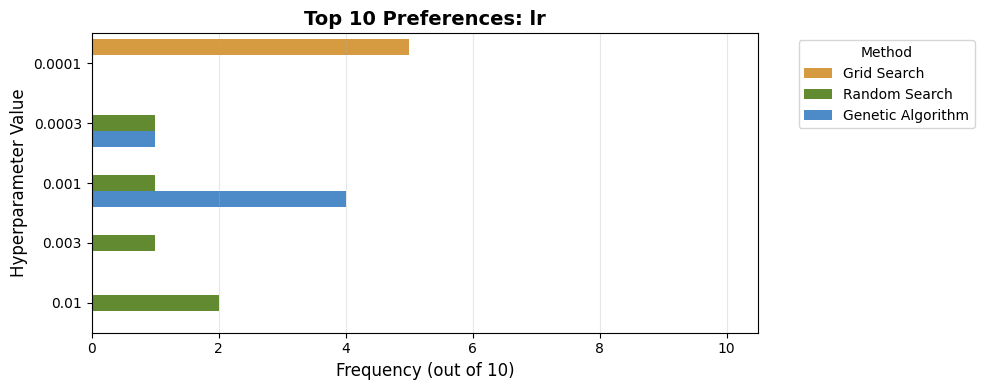

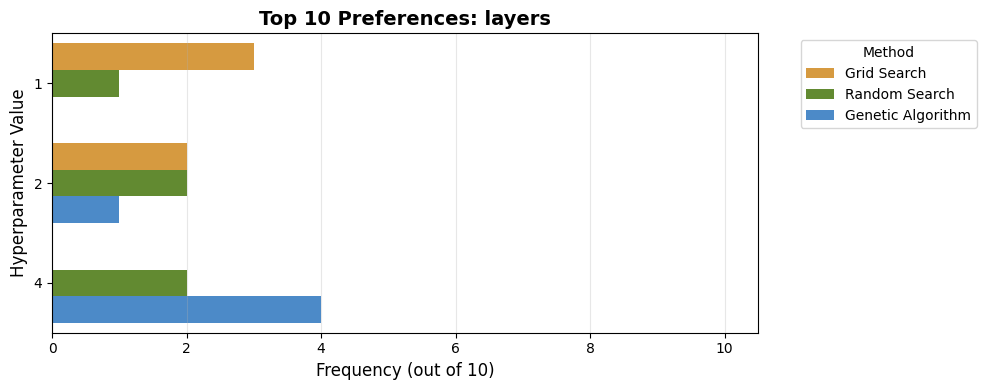

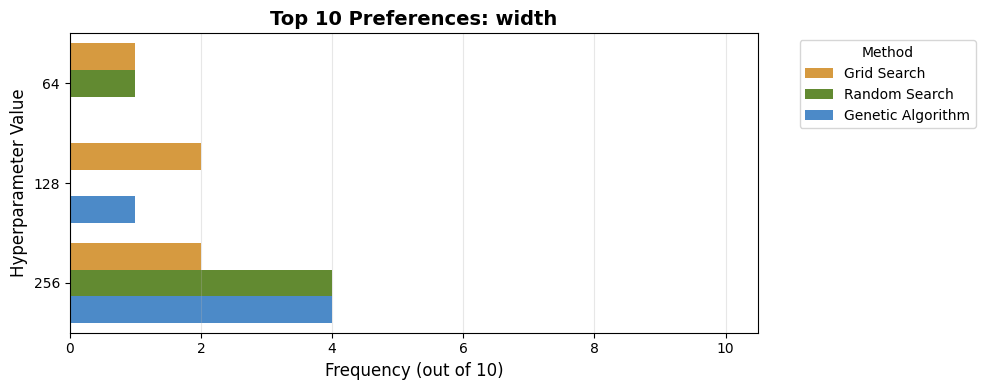

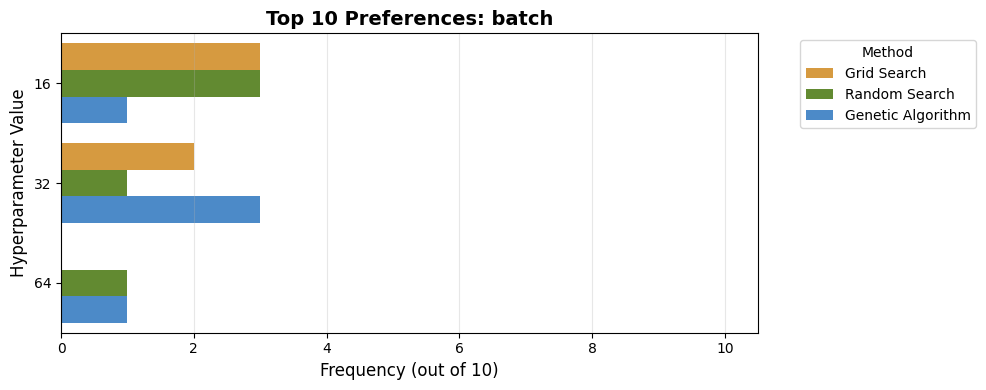

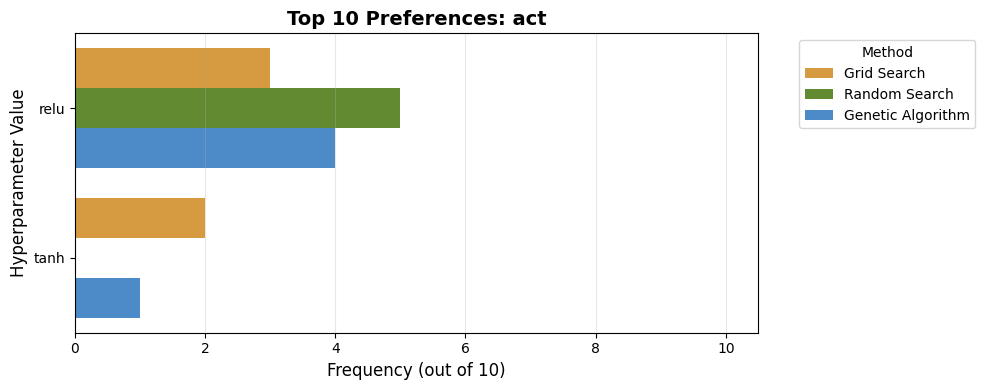

In [8]:
# Cell 8 — Hyperparameter Insights
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter

# Sorting helper Function
def sort_key(val):
    try:
        return float(val)
    except ValueError:
        return str(val)

# --- Extract Top k Configurations per Method ---

top_k = 10
methods = all_rows['method'].unique()

top_configs_per_method = {}
for method in methods:
    # Sort by best validation accuracy and take the top K
    top_df = all_rows[all_rows['method'] == method].nlargest(top_k, 'best_val_acc')
    
    # Parse the string format back into a dictionary
    parsed_cfgs = []
    for cfg_str in top_df['best_cfg']:
        cfg_dict = {}
        for part in cfg_str.split(', '):
            k, v = part.split('=')
            cfg_dict[k] = v
        parsed_cfgs.append(cfg_dict)
        
    top_configs_per_method[method] = parsed_cfgs

# Dynamically find all hyperparameter keys used in the configurations
sample_cfg = top_configs_per_method[methods[0]][0]
hp_keys = list(sample_cfg.keys())
    
# --- Generate Plot Visualizations ---

for hp in hp_keys:
    plot_data = []
    for method in methods:
        # Extract the hyperparameter value for each configuration
        values = [str(cfg.get(hp, "N/A")) for cfg in top_configs_per_method[method]]
        counts = Counter(values)
        
        for val, count in counts.items():
            plot_data.append({"Method": method, "Value": val, "Count": count})
            
    df_plot = pd.DataFrame(plot_data)
    
    # Sort values for a clean Y-axis
    sorted_y_values = sorted(df_plot["Value"].unique(), key=sort_key)
    
    # Create a NEW figure for each hyperparameter
    plt.figure(figsize=(10, 4))
    
    # Create the horizontal bar chart
    ax = sns.barplot(
        data=df_plot, 
        x="Count", 
        y="Value", 
        hue="Method", 
        palette=colors,
        order=sorted_y_values
    )
    
    plt.title(f"Top {top_k} Preferences: {hp}", fontsize=14, fontweight='bold')
    plt.xlabel(f"Frequency (out of {top_k})", fontsize=12)
    plt.ylabel("Hyperparameter Value", fontsize=12)
    plt.xlim(0, top_k + 0.5)
    
    # Format the legend to be outside the plot so it doesn't cover the bars
    plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    
    # Display the plot immediately before moving to the next hyperparameter
    plt.show()